In [1]:
from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

C:\Users\DELL\AppData\Local\Temp\ipykernel_12748\1566715015.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


ImportError: 

IMPORTANT: PLEASE READ THIS FOR ADVICE ON HOW TO SOLVE THIS ISSUE!

Importing the numpy C-extensions failed. This error can happen for
many reasons, often due to issues with your setup or how NumPy was
installed.
The following compiled module files exist, but seem incompatible
with with either python 'cpython-312' or the platform 'win32':

  * _multiarray_umath.cp314-win_amd64.lib
  * _multiarray_umath.cp314-win_amd64.pyd

We have compiled some common reasons and troubleshooting tips at:

    https://numpy.org/devdocs/user/troubleshooting-importerror.html

Please note and check the following:

  * The Python version is: Python 3.12 from "c:\Users\DELL\Desktop\CRAG\.venv\Scripts\python.exe"
  * The NumPy version is: "2.5.2"

and make sure that they are the versions you expect.

Please carefully study the information and documentation linked above.
This is unlikely to be a NumPy issue but will be caused by a bad install
or environment on your machine.

Original error was: 

In [20]:
docs = (
    PyPDFLoader("C:\\Users\\DELL\\Desktop\\CRAG\\documents\\Aligarah_Movement.pdf").load() +
    PyPDFLoader("C:\\Users\\DELL\\Desktop\\CRAG\\documents\\course_note_CMU_NLP_Lecture1_5.pdf").load() +
    PyPDFLoader("C:\\Users\\DELL\\Desktop\\CRAG\\documents\\Full_Stack.pdf").load()
)

In [21]:
len(docs)

42

In [22]:
# 2) Chunk
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

# 3) Clean text to avoid UnicodeEncodeError (surrogates from PDF extraction)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [23]:
len(chunks)

67

In [24]:
# 3) Index (fresh collection each run)
embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
vector_store = FAISS.from_documents(chunks, embeddings)

c:\Users\DELL\Desktop\CRAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2516.47it/s]


In [25]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [26]:
# 4) LLM + prompt
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")

In [27]:
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str

In [28]:
def retrieve(state):
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [29]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)
def generate(state):
    context = "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | llm).invoke({"question": state["question"], "context": context})
    return {"answer": out.content}

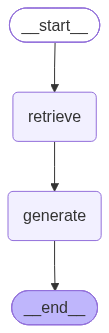

In [30]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("generate", generate)
g.add_edge(START, "retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate", END)
app = g.compile()

app

In [35]:
# 5) Run
res = app.invoke({"question": "who is elon mask", "docs": [], "answer": ""})
res["answer"][0]['text']

"I don't know."

In [36]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

Adam is widely used for training modern models such as Transformers:
mt = β1mt−1 + (1 − β1)gt, (3)
vt = β2vt−1 + (1 − β2)g2
t , (4)
ˆmt = mt
1 − βt
1
, ˆvt = vt
1 − βt
2
, (5)
θt = θt−1 − η√ˆvt + ϵ ˆmt. (6)
8
****************************************************************************************************
36.2 Self-Attention
Self-attention allows each element in a sequence to attend to all other ele-
ments in the same sequence, providing contextual representations (https://arxiv.org/abs/1601.06733,
https://arxiv.org/abs/1706.03762). The attention mechanism is formulated
similarly to cross-attention, except that keys, queries, and values all come
from the same sequence.
Transcript Insights: The transcript highlights how self-attention enables
context-sensitive encodings. Each token can incorporate global dependen-
cies efficiently, unlike recurrent architectures that struggle with long-range
dependencies.
37 Transformer Architecture
Transformers consist of stacked layers composed of 